# Closing the loop: mouse HD data → the order parameter m(θ, t)

Projects binned spiking from one Peyrache HD session onto that session's measured tuning curves, yielding the empirical order parameter m(θ, t) next to the animal's true head direction. Produces the cache `data/closing_the_loop.npz`, consumed by `data_driven_attractor.ipynb` as panel l of Fig 2; this notebook produces no paper figure itself.

In [1]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
REGENERATE_CACHES = False

import numpy as np
from pynwb import NWBHDF5IO
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from ring import data
from ring import style
#from ring.data_driven import circular_com

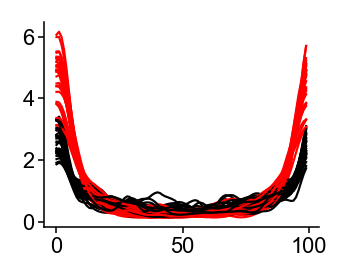

In [2]:
def circular_com(data, return_idx=False):
    #data = (N_curves, N_theta)
    theta = np.linspace(0, 2*np.pi, data.shape[1], endpoint=False)
    x_comp = np.sum(data * np.cos(theta), axis=1)
    y_comp = np.sum(data * np.sin(theta), axis=1)
    result = np.arctan2(y_comp, x_comp) % (2*np.pi)
    if not return_idx:
        return result
    else:
        return np.floor(result*data.shape[1]/(2*np.pi)).astype(int)


tc_data_path = "../data/mouse_data/tc_data.npz"

tc_data = np.load(tc_data_path)
hd_mask, exc_mask, fs_mask = tc_data['hd_mask'], tc_data['exc_mask'], tc_data['fs_mask']
unit_counts = tc_data['unit_counts']
tuning_curves = tc_data['opt_tcs'].mean(1)

session_tcs = []
for i, count in enumerate(unit_counts):
    start = np.sum(unit_counts[:i])
    stop = start + count
    msk = (hd_mask & exc_mask)[start:stop]
    tcs = tuning_curves[start:stop]
    hd_tcs = tcs[msk]
    bad = np.sum(hd_tcs, axis=1) < 1e-6
    hd_tcs = hd_tcs[~bad]
    session_tcs.append(hd_tcs)

for session_idx, X in enumerate(session_tcs):
    coms = (100 * circular_com(X)/(2*np.pi)).astype(int)
    X_rot = np.copy(X)
    for unit_idx in range(len(X)):
        X_rot[unit_idx] = np.roll(X[unit_idx], -coms[unit_idx])
    X_rot = X_rot / X_rot.mean(1, keepdims=True)
    mean, std = X_rot.mean(0), X_rot.std(0)
    plt.plot(mean, c='red')
    plt.plot(std, c='black')
    



## Load the session with the most HD units

Session choice is not hand-picked: it is `argmax` over per-session HD-unit counts, so the selection is reproducible from the cache. Spikes are binned into `data.DATA_DT` bins over the `wake_square` epoch only, so the HD signal and the spike counts share one clock.

In [32]:
"""
Load data
"""

session_info = data.get_session_info()
all_fnames = [x[0] for x in session_info]

tc_data = np.load(tc_data_path)
hd_mask, exc_mask, fs_mask = tc_data['hd_mask'], tc_data['exc_mask'], tc_data['fs_mask']
unit_counts = tc_data['unit_counts']

hd_counts = np.array([np.sum(hd_mask[np.sum(unit_counts[:i]):np.sum(unit_counts[:i+1])]) for i in range(len(unit_counts))])
session_index = np.argsort(hd_counts)[::-1][0]

print(f"Loading session {session_index} with {hd_counts[session_index]} HD units")

nwb_file = all_fnames[session_index]
with NWBHDF5IO(nwb_file, mode="r") as io:
    nwbfile = io.read()
    session_id = nwbfile.session_id
    hd_spatial_series = nwbfile.processing["behavior"].data_interfaces["CompassDirection"].spatial_series["head-direction"]
    hd_full, t_full = hd_spatial_series.data[:], hd_spatial_series.timestamps[:]
    
    epoch_df = nwbfile.epochs.to_dataframe()
    ti_nominal, tf_nominal = epoch_df[epoch_df["tags"] == "wake_square"][["start_time", "stop_time"]].values[0]
    
    ti_idx, tf_idx = np.argmin((ti_nominal - t_full)**2), np.argmin((tf_nominal - t_full)**2)
    hd, t = hd_full[ti_idx:tf_idx], t_full[ti_idx:tf_idx]
    print(hd, data.DATA_DT)
    
    units = nwbfile.units
    num_units = len(units)
    temporal_spike_counts = np.zeros((tf_idx - ti_idx, num_units), dtype=int)
    
    for i in range(num_units):
        spike_times = units['spike_times'][i][:]
        within_epoch_spike_times = spike_times[(spike_times >= t[0]) & (spike_times < t[-1])]
        spike_time_idx = np.floor((within_epoch_spike_times - t[0])/data.DATA_DT).astype(int)
        unique_spike_time_idx, spike_time_idx_counts = np.unique(spike_time_idx, return_counts=True)
        temporal_spike_counts[unique_spike_time_idx, i] = spike_time_idx_counts

session_start_idx = np.sum(unit_counts[:session_index])
session_end_idx = session_start_idx + unit_counts[session_index]

tuning_curves = tc_data['opt_tcs'][session_start_idx:session_end_idx]
session_hd_mask = hd_mask[session_start_idx:session_end_idx]
session_exc_mask = exc_mask[session_start_idx:session_end_idx]
session_fs_mask = fs_mask[session_start_idx:session_end_idx]


print(f"Loaded data for {len(session_hd_mask)} units over {len(t)} time points.")
print(f"Head direction shape: {hd.shape}")
print(f"Spike counts shape: {temporal_spike_counts.shape}")
print(f"Tuning curves shape: {tuning_curves.shape}")
print(f"Number of HD units: {np.sum(session_hd_mask)}")
print(f"Number of excitatory units: {np.sum(session_exc_mask)}")
print(f"Number of fast-spiking units: {np.sum(session_fs_mask)}")

Loading session 10 with 117 HD units
200317
[2.00828405 2.00413191 1.99832171 ... 2.50798228 2.50600483 2.51189706] 0.01
Loaded data for 185 units over 180304 time points.
Head direction shape: (180304,)
Spike counts shape: (180304, 185)
Tuning curves shape: (185, 2, 100)
Number of HD units: 117
Number of excitatory units: 125
Number of fast-spiking units: 30


In [49]:
if REGENERATE_CACHES:
    np.savez("../data/actual_hd_timeseries_2.npz", hd=hd, dt=data.DATA_DT)

## Sanity check: stored tuning curves vs. curves recomputed from spikes

Re-deriving one unit's tuning curve directly from the spike train and the HD signal checks that the binning and epoch alignment above reproduce the curves stored in `tc_data.npz`.

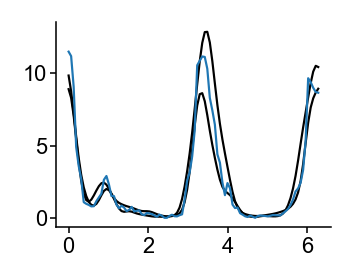

In [36]:
"""
Sanity check
"""

unit_idx = np.where(session_hd_mask)[0][20]

theta = np.linspace(0, 2*np.pi, tuning_curves.shape[2])
plt.plot(theta, tuning_curves[unit_idx, 0, :], label='Stored Tuning Curve', c='black')
plt.plot(theta, tuning_curves[unit_idx, 1, :], c='black')

theta_vals = np.linspace(0, 2*np.pi, 100)
frs = [temporal_spike_counts[:, unit_idx][np.abs(hd - theta_val) < np.pi/50].mean() / data.DATA_DT for theta_val in theta_vals]
plt.plot(theta_vals, frs, label='Computed from Spikes')




## Scratch: NWB structure and epoch checks

Exploratory cells kept for provenance — they inspect a second session's NWB layout, epoch boundaries, timestamp regularity, and the NaN fraction of the HD trace. Nothing below depends on them; they can be skipped on a read-through.

In [33]:
session_index = 10
io = NWBHDF5IO(all_fnames[session_index], mode="r")
nwbfile = io.read()

nwbfile

,location,group,group_name,label,is_faulty,x,y,z,filtering
id,,,,,,,,,
0,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec0,False,0.0,787.5,0.0,none
1,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec1,False,0.0,775.0,0.0,none
2,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec2,False,0.0,762.5,0.0,none
3,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec3,False,0.0,750.0,0.0,none
,location,group,group_name,label,is_faulty,x,y,z,filtering
id,,,,,,,,,
0,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec0,False,0.0,787.5,0.0,none
1,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec1,False,0.0,775.0,0.0,none
2,Postsubiculum (left hemisphere),"shank0 pynwb.ecephys.ElectrodeGroup at 0x140291515409248\nFields:\n description: electrode group for shank0\n device: Cambridge Neurotech H5 probe pynwb.device.Device at 0x140291784122080\nFields:\n description: 64-channel linear array, 12.5 um channel spacing, implanted at 20deg angle, approximately parallel to cortical layers. Channels sorted top to bottom of shank. \n\n location: Postsubiculum (left hemisphere)\n",shank0,shank0elec2,False,0.0,762.5,0.0,none


In [38]:
position_spatial_series = nwbfile.processing["behavior"].data_interfaces["Position"].spatial_series["position"]
hd_spatial_series = nwbfile.processing["behavior"].data_interfaces["CompassDirection"].spatial_series["head-direction"]

position_spatial_series.timestamps[:], hd_spatial_series.timestamps[:]

(array([ 3922.994,  3923.004,  3923.014, ..., 11267.39 , 11267.4  ,
        11267.41 ]),
 array([ 3922.994,  3923.004,  3923.014, ..., 11267.39 , 11267.4  ,
        11267.41 ]))

In [39]:
sts = nwbfile.units[37].spike_times.values[0]
sts.min(), sts.max()

(0.0305, 11270.54855)

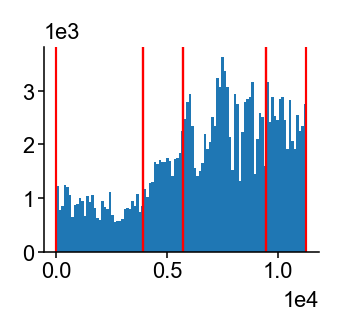

,start_time,stop_time,tags
id,,,
0,0.00005,3919.284,[home_cage]
1,3919.28400,5728.428,[wake_square]
2,5728.42800,9464.220,[home_cage]
3,9464.22000,11270.560,[wake_triangle]


In [40]:
plt.hist(sts, bins=100)
epocht = nwbfile.epochs[:][["start_time", "stop_time"]].values.flatten()
for t in epocht:
    plt.axvline(t, c='red')

plt.show()

nwbfile.epochs

In [47]:
epoch_df = nwbfile.epochs.to_dataframe()
ti, tf = epoch_df[epoch_df["tags"] == "wake_square"][["start_time", "stop_time"]].values[0]
t = hd_spatial_series.timestamps[:]

np.diff(t[(t>ti)&(t<tf)])

array([0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01])

In [12]:
np.mean(np.isnan(hd))*100

3.366222350473358

In [4]:
hd.shape

(180304,)

In [5]:
tuning_curves.shape, temporal_spike_counts.shape, session_hd_mask.shape

((185, 2, 100), (180304, 185), (185,))

In [21]:
temporal_spike_counts.shape

(180304, 185)

## Compute the order parameter m(θ, t)

Normalizes each HD unit's tuning curve by its mean rate, coarse-bins the spike counts by `temporal_bin_size` (10 → 100 ms bins), and contracts the two against each other. m(θ, t) is the data-side analogue of the model bump: it peaks at the θ the population currently encodes.

In [6]:


def compute_m_order_parameter(spikes, tuning_curves, hd_mask, temporal_bin_size):
    spikes_hd = spikes[:, hd_mask]
    tc = tuning_curves.mean(1)[hd_mask]
    
    factors = 1. / (tc.mean(1) + 1e-12)
    X = tc * factors[:, None]
    
    N_bins = len(spikes) // temporal_bin_size
    spikes_coarse = np.array([spikes_hd[i*temporal_bin_size:(i+1)*temporal_bin_size].mean(axis=0) for i in range(N_bins)])
    
    Xt = spikes_coarse * factors[None, :]
    
    m = np.einsum('ia,it->at', X, Xt.T, optimize='optimal') / len(factors)
    
    return m, Xt, X

temporal_bin_size = 10
m, Xt, X = compute_m_order_parameter(temporal_spike_counts, tuning_curves, session_hd_mask, temporal_bin_size)
print(f"m shape: {m.shape}")

m shape: (100, 18030)


## Producer (disabled): `data/closing_the_loop.npz`

Rotates m and the HD trace so the session starts at θ = 0, then writes the cache consumed by `data_driven_attractor.ipynb`. The `np.savez` is guarded by `REGENERATE_CACHES` (default `False`) so re-runs don't overwrite the verified baseline; set it `True` to regenerate. The saved `hd` is the **pre**-discontinuity-removal `hd_roll`: the consumer calls `remove_discontinuities_mod_2pi` itself, and saving the post-removal array would apply it twice (the producer/consumer-contract bug documented as F1 in `EQUIVALENCE_LEDGER.md`).

In [ ]:
from ring import data_driven

roll_amt = hd[0]
hd_roll = np.mod(hd - roll_amt, 2*np.pi)
m_roll = np.roll(m, -int(roll_amt*m.shape[0]/(2*np.pi)), axis=0)

hd_ctl = data_driven.remove_discontinuities_mod_2pi(hd_roll)

# Regenerate the closing_the_loop.npz cache consumed by notebooks/data_driven_attractor.ipynb
# (Fig 2 plot_ctl panel). Save the pre-discontinuity-removal hd_roll: the consumer in
# data_driven_attractor.ipynb cell 18 calls remove_discontinuities_mod_2pi itself on the loaded hd.
# Producer for closing_the_loop.npz (consumed by data_driven_attractor, Fig 2).
# Guarded by REGENERATE_CACHES (default False) so re-runs cannot overwrite the baseline.
if REGENERATE_CACHES:
    np.savez(
        "../data/closing_the_loop.npz",
        m=m_roll, hd=hd_roll, m_dt=0.1, hd_dt=0.01,
    )

fig, ax = plt.subplots()
data_driven.plot_head_direction(
    ax, m=m_roll[:, :900].T, hd=hd_ctl, m_dt=0.1, hd_dt=0.01
)


## Local plotting helpers

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def circular_mean(angles, axis=None):
    return np.angle(np.mean(np.exp(1j*angles), axis=axis))

def circular_com(data):
    theta = np.linspace(0, 2*np.pi, data.shape[1], endpoint=False)
    x_comp = np.sum(data * np.cos(theta), axis=1)
    y_comp = np.sum(data * np.sin(theta), axis=1)
    return np.arctan2(y_comp, x_comp) % (2*np.pi)

def plot_activity_with_hd(activity, hd, start, end, temporal_bin_size, ax=None, title=None, ylabel=None):
    time_range = (end - start) * temporal_bin_size * data.DATA_DT
    
    vmax = np.percentile(activity[:, start:end], 97.5)

    if ax is None:
        plt.figure(figsize=(8, 1), dpi=200)
        ax = plt.gca()
    im = ax.imshow(activity[:, start:end], vmin=0, vmax=vmax, aspect="auto", 
                   extent=[0, time_range, 0, 2*np.pi], origin='lower', cmap=style.field_cmap('ice'), 
                   interpolation="None")

    if hd is not None:
        t_hd = np.linspace(0, time_range, (end-start)*temporal_bin_size)
        vals_hd = hd[start*temporal_bin_size:end*temporal_bin_size]
        vals_hd[np.concatenate(([False], np.abs(np.diff(vals_hd)) > np.pi))] = np.nan
        ax.plot(t_hd, vals_hd, color='red', lw=1, ls='-', alpha=1, zorder=100)

    ax.set_xlabel('time (s)')
    ax.set_ylabel('θ' if ylabel is None else ylabel)
    if title:
        ax.set_title(title)

    ax.set_yticks([0, np.pi, 2*np.pi], ['0', '$\\pi$', '$2\\pi$'])
    
    return im



In [41]:
hd.shape #, m.shape

(180202,)

[0.                nan        nan ... 5.78713945 5.76464146 5.75328914]


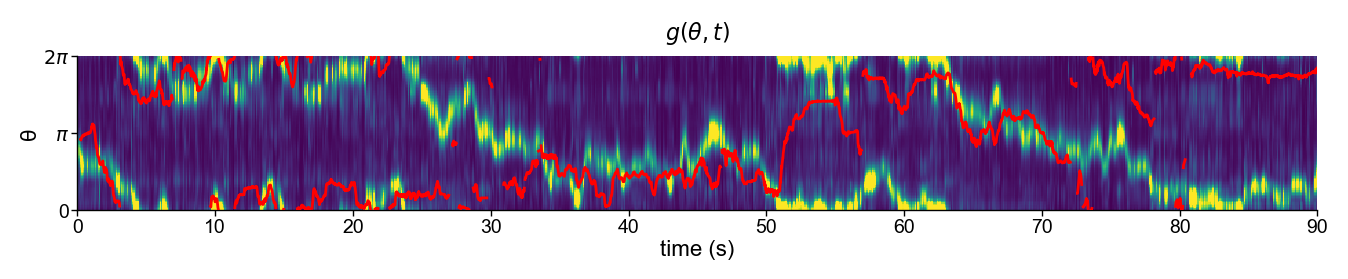

In [39]:
"""
Plot m
"""

start = int(0 / temporal_bin_size)
end = start + int(9000 / temporal_bin_size)

# Plot m order parameter
hd_roll = np.mod(-hd[0] + hd, 2*np.pi)
roll_amt = int(hd[0] * 100 / (2*np.pi))
m_roll = np.roll(m, -roll_amt, axis=0)
plot_activity_with_hd(m_roll, hd_roll, start, end, temporal_bin_size, title="$g(\\theta, t)$")

plt.show()

## m(θ, t) against measured head direction

Both panels are rotated to start at θ = 0 and share a time axis; the red HD overlay tracking the bright ridge of m is the "closing the loop" result.

TypeError: plot_activity_with_hd() got multiple values for argument 'title'

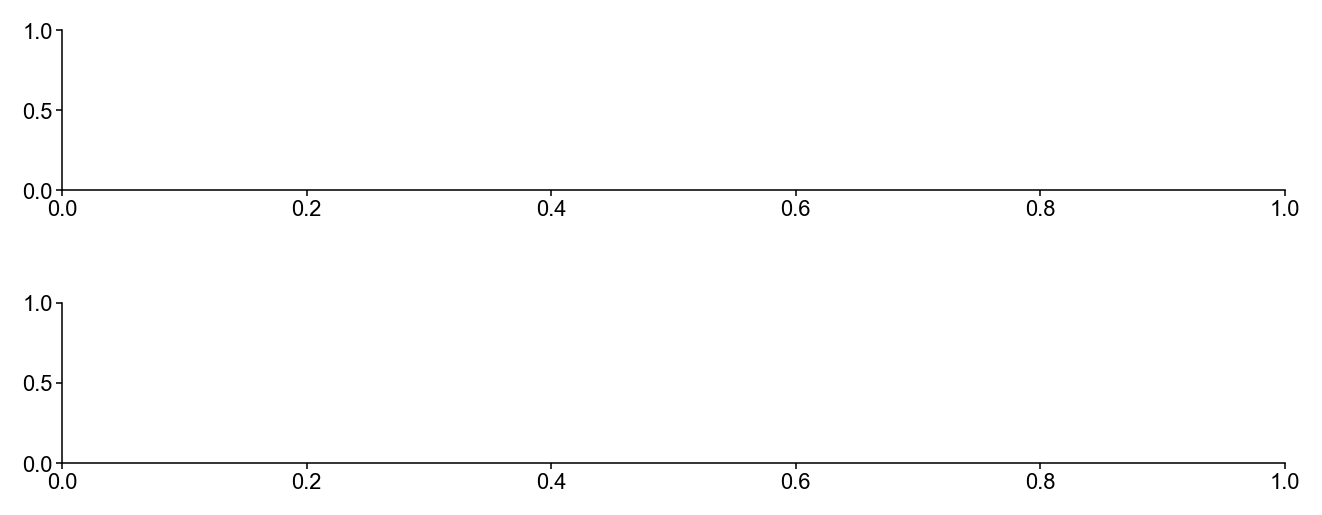

In [35]:
"""
Plot m
"""

start = int(0 / temporal_bin_size)
end = start + int(10000 / temporal_bin_size)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.01, 2.5), sharex=False)
fig.subplots_adjust(hspace=0.7)

# Plot m order parameter
plot_activity_with_hd(m, hd, start, end, temporal_bin_size, ax1, title="$g(\\theta, t)$")

# Plot sorted neural activity
com = circular_com(X)
order = np.argsort(com)
plot_activity_with_hd(Xt[:, order].T, None, start, end, temporal_bin_size, ax2, 
                      title="binned spiking activity",
                      ylabel='neuron index')

plt.show()

## Turn-conditioned bump asymmetry (exploratory)

Splits timepoints by angular velocity (right / left / slow at a 0.4 rad/bin threshold), peak-aligns m in each class, and takes the right-minus-left difference to look for a velocity-dependent shift of the bump. Exploratory — no paper figure consumes this.

In [ ]:
hd_clean = hd.copy()
hd_clean = hd_clean[::temporal_bin_size]
hd_clean[np.concatenate(([False], np.abs(np.diff(hd_clean)) > np.pi))] = np.nan

plt.hist(np.diff(hd_clean), bins=500)
plt.yscale('log')
plt.axvline(0.4, c='red')
plt.show()

THRESH = 0.4
right_idx = np.diff(hd_clean) > THRESH
left_idx = np.diff(hd_clean) < -THRESH
slow_idx = np.abs(np.diff(hd_clean)) < THRESH

In [ ]:
m_roll = m.copy()
for i in range(m.shape[1]):
    m_roll[:, i] = np.roll(m[:, i], 50-np.argmax(m[:, i])) / (m[:, i].max() + 1e-12)

m_right = m_roll[:, right_idx].mean(1)
m_left = m_roll[:, left_idx].mean(1)
m_slow = m_roll[:, slow_idx].mean(1)
diff = m_right - m_left

m_left_std = m_roll[:, left_idx].std(1)
m_right_std = m_roll[:, right_idx].std(1)
diff_std = m_left_std + m_right_std


plt.plot(diff)
plt.fill_between(x=np.arange(100), y1=diff-diff_std, y2=diff+diff_std)


plt.axvline(50)
